# Decision Tree Classifier

## Blocks
1. Categorical-safe preprocessing
2. Outlier detection and removal (rare-category rule)
3. Model-specific preprocessing
4. Training, metrics, and visualization

## 1) Imports and Shared Helpers

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def resolve_dataset_path():
    candidates = [
        Path.cwd() / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent.parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('Cannot find Mushroom Dataset/mushrooms 2.csv from current location.')

def load_and_clean_data(rare_threshold=0.01):
    df = pd.read_csv(resolve_dataset_path())
    df = df.replace('?', np.nan).drop_duplicates().copy()

    for c in df.columns:
        if df[c].isna().any():
            if pd.api.types.is_numeric_dtype(df[c]):
                df[c] = df[c].fillna(df[c].mean())
            else:
                mode_val = df[c].mode(dropna=True)
                df[c] = df[c].fillna(mode_val.iloc[0] if not mode_val.empty else 'missing')

    outlier_mask = pd.Series(False, index=df.index)
    outlier_cols = []
    min_count = max(1, int(rare_threshold * len(df)))

    for c in df.columns:
        if c == 'class':
            continue
        counts = df[c].value_counts(dropna=False)
        rare_vals = counts[counts < min_count].index
        if len(rare_vals) > 0:
            is_rare = df[c].isin(rare_vals)
            outlier_mask = outlier_mask | is_rare
            outlier_cols.append(c)

    df['is_outlier'] = outlier_mask.astype(int)
    single_cols = [c for c in df.columns if c != 'is_outlier' and df[c].nunique() <= 1]
    if single_cols:
        df = df.drop(columns=single_cols)

    return df, outlier_cols

## 2) Model Pipeline

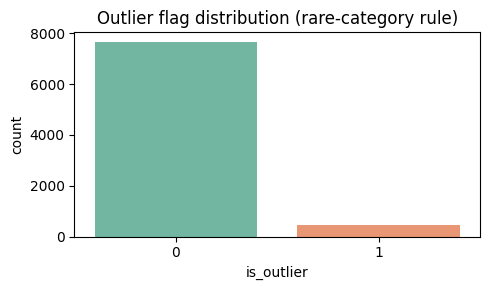

Rows after outlier removal: 7651
Columns triggering outlier flags: ['cap-shape', 'cap-surface', 'cap-color', 'odor', 'gill-color', 'stalk-surface-above-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color']
accuracy     0.9987
precision    1.0000
recall       0.9974
f1           0.9987
roc_auc      0.9987
dtype: float64

Classification report:
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       775
   poisonous       1.00      1.00      1.00       756

    accuracy                           1.00      1531
   macro avg       1.00      1.00      1.00      1531
weighted avg       1.00      1.00      1.00      1531



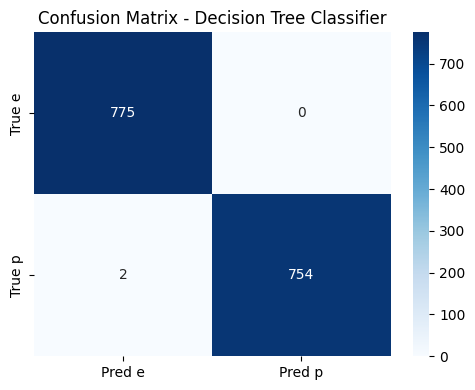

C:\Users\Ahmed Fahmy\AppData\Local\Temp\ipykernel_75468\1436520731.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


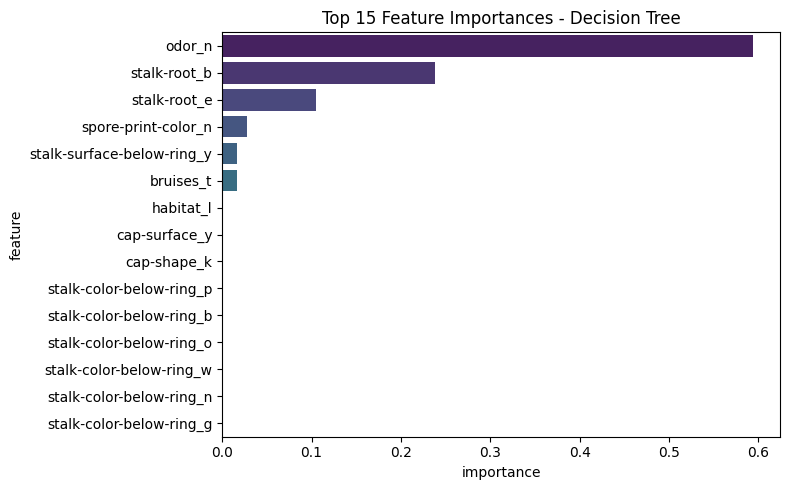

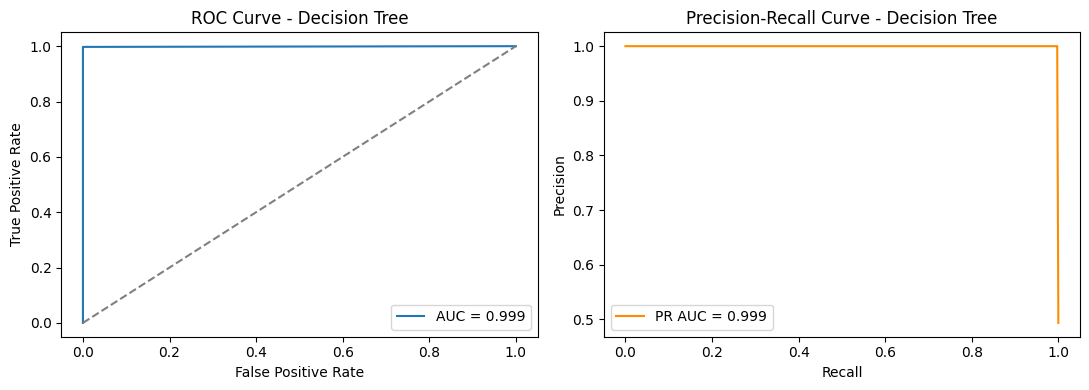

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.tree import DecisionTreeClassifier

df_all, outlier_cols = load_and_clean_data(rare_threshold=0.01)

plt.figure(figsize=(5, 3))
sns.countplot(x='is_outlier', data=df_all, hue='is_outlier', palette='Set2', legend=False)
plt.title('Outlier flag distribution (rare-category rule)')
plt.tight_layout()
plt.show()

df = df_all[df_all['is_outlier'] == 0].drop(columns=['is_outlier']).copy()
print('Rows after outlier removal:', len(df))
print('Columns triggering outlier flags:', outlier_cols)

y = df['class'].map({'e': 0, 'p': 1}).astype(int)
X = df.drop(columns=['class'])
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train = ohe.fit_transform(X_train_raw)
X_test = ohe.transform(X_test_raw)

model = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=12, min_samples_leaf=4)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob),
}
print(pd.Series(metrics).round(4))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['edible', 'poisonous']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred e', 'Pred p'], yticklabels=['True e', 'True p'])
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.tight_layout()
plt.show()

feature_names = ohe.get_feature_names_out(X_train_raw.columns)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_curve, precision_curve)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, label=f'AUC = {metrics["roc_auc"]:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curve - Decision Tree')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f'PR AUC = {pr_auc:.3f}', color='darkorange')
axes[1].set_title('Precision-Recall Curve - Decision Tree')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()